# Chapter 16: Raster-Vector Integration Patterns

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Choose the right substrate for each operation
- Convert between vector and raster without losing precision
- Build proximity drivers using distance transforms

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.transform import from_origin
from scipy import ndimage

## When to Use Which Substrate

Every chapter since Chapter 6 has picked one substrate — vector or raster — and stayed there for the whole chapter. Real analyses rarely get that luxury: a coastal study might need exact **municipality boundaries** (vector, from Chapter 7) evaluated against a **satellite-derived mangrove cover raster** (Chapter 8), or a **distance to the nearest monitoring station** (naturally a vector distance) expressed as a continuous surface every raster cell can read (naturally raster). This chapter is about the seam between them, not about picking a winner.

A small synthetic study area — a stand-in for a stretch of Maranhão's coast, small enough to keep every operation in this chapter instant — sets up the running example:

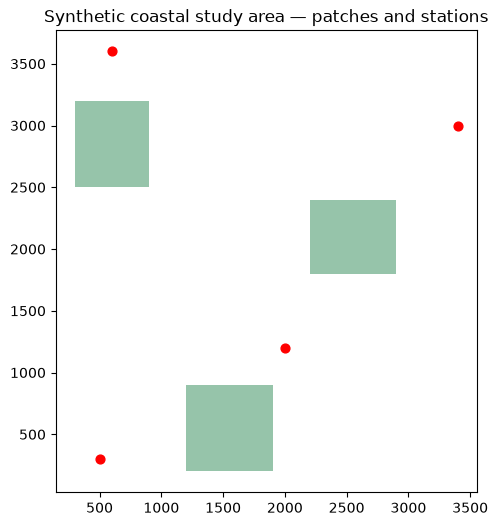

In [2]:
from shapely.geometry import box, Point

# A 40x40 cell raster grid, 100m resolution, arbitrary local origin
width, height, res = 40, 40, 100.0
transform = from_origin(0, height * res, res, res)  # top-left origin, north-up

# Three protected/mangrove patches, as vector polygons in the same coordinate space
patches = gpd.GeoDataFrame(
    {"patch_id": [1, 2, 3], "name": ["Mangrove A", "Mangrove B", "Dune Reserve"]},
    geometry=[
        box(300, 2500, 900, 3200),
        box(2200, 1800, 2900, 2400),
        box(1200, 200, 1900, 900),
    ],
)

# Four monitoring stations, as points
stations = gpd.GeoDataFrame(
    {"station": ["S1", "S2", "S3", "S4"]},
    geometry=[Point(600, 3600), Point(3400, 3000), Point(2000, 1200), Point(500, 300)],
)

fig, ax = plt.subplots(figsize=(6, 6))
patches.plot(ax=ax, color="seagreen", alpha=0.5)
stations.plot(ax=ax, color="red", markersize=40)
ax.set_title("Synthetic coastal study area — patches and stations")
plt.show()

The rule of thumb that resolves most substrate choices: stay in **vector** when precision matters and objects are genuinely discrete (a protected area's legal boundary, a station's exact coordinate) — stay in **raster** when the phenomenon is naturally continuous, or when the same operation needs to run identically over thousands of cells at once (Chapter 8's focal filters, or the distance surface this chapter builds shortly). Neither choice is permanent within one analysis, which is exactly why converting cleanly between them, in both directions, is worth a whole chapter.

## Vector to Raster: rasterio.features.rasterize()

`rasterio.features.rasterize()` burns vector geometries directly into a raster grid: every cell whose center falls inside a geometry gets a specified value, every other cell gets a fill value. It needs exactly the two things that tie a raster to real-world space, both already in hand — a `transform` and an output `shape` — plus a sequence of `(geometry, value)` pairs to burn:

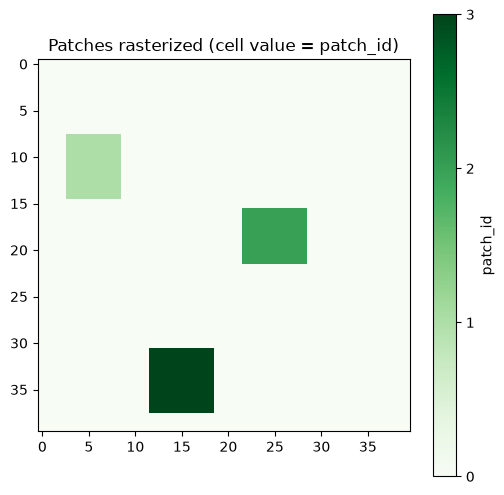

In [3]:
shapes_and_values = zip(patches.geometry, patches["patch_id"])

patch_raster = features.rasterize(
    shapes=shapes_and_values,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="int32",
)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(patch_raster, cmap="Greens", vmin=0, vmax=3)
ax.set_title("Patches rasterized (cell value = patch_id)")
fig.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], label="patch_id")
plt.show()

Every cell now carries its patch's `patch_id` (or `0`, outside every patch) as a plain integer — the same array format Chapter 8's raster algebra and focal operations work on directly. This is the step that lets a model choose a raster substrate for cells that started life as vector polygons, exactly the choice Chapter 7 and Chapter 8 both previewed as a decision DisSModel's model classes make explicit.

## Raster to Vector: rasterio.features.shapes()

`features.shapes()` runs the conversion in reverse: group a raster's cells into contiguous regions of equal value, and emit each region as a vector polygon. It's the natural next step after any raster classification — Chapter 8's `highlands = elevation > 900` boolean mask is exactly this kind of input, ready to become "the polygon outlining every highland area" instead of "the pixels above 900m":

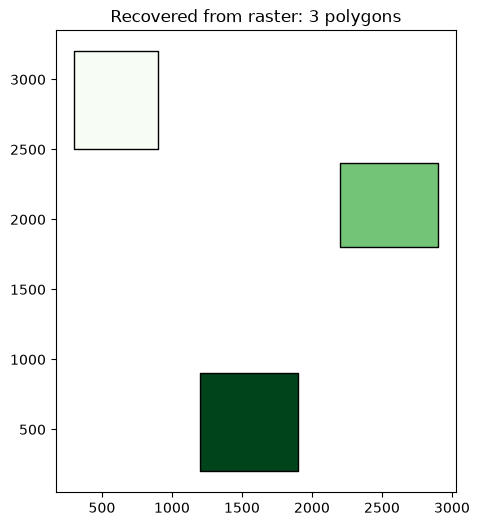

In [4]:
shapes_generator = features.shapes(patch_raster.astype("int32"), transform=transform)

recovered_polygons = [
    {"patch_id": value, "geometry": gpd.GeoSeries.from_wkt([__import__("shapely").geometry.shape(geom).wkt])[0]}
    for geom, value in shapes_generator
    if value != 0  # skip the background (fill=0) region
]
recovered = gpd.GeoDataFrame(recovered_polygons)

fig, ax = plt.subplots(figsize=(6, 6))
recovered.plot(ax=ax, column="patch_id", cmap="Greens", edgecolor="black")
ax.set_title(f"Recovered from raster: {len(recovered)} polygons")
plt.show()

The recovered polygons should closely match the original three rectangles — "closely," not exactly, because rasterizing and then re-vectorizing necessarily snaps every boundary to the 100 m grid Chapter 8's substrate discussion warned about. A vector boundary drawn once and kept in vector form the whole way through never loses that precision; one that makes a round trip through a raster grid does, by exactly one cell's worth of resolution at every edge.

## Zonal Statistics with rasterstats

Rasterizing and vectorizing convert geometry itself between substrates. **Zonal statistics** does something different and, in practice, far more common: it keeps the vector polygons as-is and asks what a raster looks like *inside* each one — the mean elevation per municipality, the maximum rainfall per watershed. `rasterstats.zonal_stats()` takes the same `raster` + `affine` pairing rasterize needed, plus the vector zones themselves:

In [5]:
from rasterstats import zonal_stats

np.random.seed(0)
# A synthetic vegetation-density raster, 0-1, with three deliberately different mean levels
veg = np.random.rand(height, width) * 0.3
veg[10:20, 3:9] += 0.6    # boosts the cells under "Mangrove A"
veg[16:24, 22:29] += 0.3  # boosts the cells under "Mangrove B"
veg = np.clip(veg, 0, 1)

stats = zonal_stats(patches, veg, affine=transform, stats=["mean", "min", "max", "count"])
for name, s in zip(patches["name"], stats):
    print(f"{name:15s} mean={s['mean']:.2f}  min={s['min']:.2f}  max={s['max']:.2f}  cells={s['count']}")

Mangrove A      mean=0.60  min=0.08  max=0.90  cells=42
Mangrove B      mean=0.42  min=0.30  max=0.59  cells=42
Dune Reserve    mean=0.14  min=0.01  max=0.30  cells=49


/home/sergio/develop/github/lambdageo/ebooks/geospatial-modeling-python/.venv/lib/python3.12/site-packages/rasterstats/io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


"Mangrove A" and "Mangrove B" should come back with a visibly higher mean than "Dune Reserve," exactly matching the deliberate boost written into the synthetic raster — the same operation applied to a real vegetation index would answer the real question directly, no manual pixel-counting required. `count` matters as a sanity check in its own right: a suspiciously small count usually means a small polygon barely overlapping any cell centers, not a computation error.

## Distance Transforms: Vector to Proximity Driver

A model that cares about "distance to the nearest monitoring station" needs that distance at *every* cell, not just at the four station points themselves — a continuous proximity surface, derived from discrete vector points. The direct way to compute it: rasterize the stations, then let `scipy.ndimage.distance_transform_edt` compute, for every cell, the Euclidean distance to the nearest cell that isn't background:

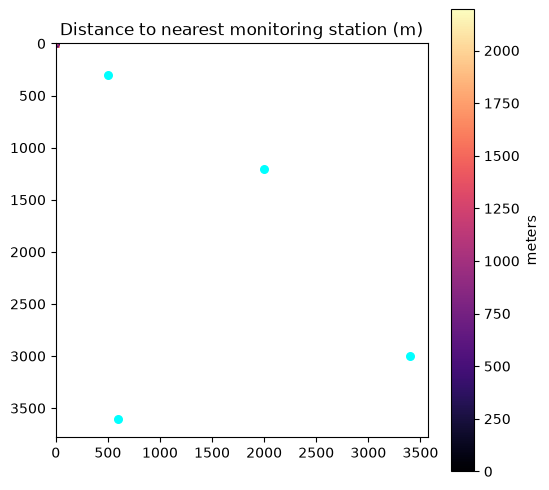

In [6]:
station_raster = features.rasterize(
    shapes=[(geom, 1) for geom in stations.geometry],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8",
)

# distance_transform_edt measures distance FROM zero cells TO the nearest nonzero one,
# so invert the mask: stations become 0, everything else becomes "far from a station"
distance_cells = ndimage.distance_transform_edt(station_raster == 0)
distance_map = distance_cells * res  # cells -> meters, using this raster's 100m resolution

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(distance_map, cmap="magma")
stations.plot(ax=ax, color="cyan", markersize=30)
ax.set_title("Distance to nearest monitoring station (m)")
fig.colorbar(im, ax=ax, label="meters")
plt.show()

Every cell in `distance_map` now carries a real, physically meaningful distance in meters — usable directly as a model input (a fire risk model down-weighting areas far from a response station, a habitat model rewarding proximity to a water source) without a single explicit distance calculation written by hand.

## Performance Patterns for Integration

There's a second way to get that same distance map, and it's worth trying deliberately, once, to feel the difference: loop over every cell, and for each one, compute its distance to every station directly with vector geometry — precisely the approach `.geometry.apply(lambda p: stations.distance(p).min())` takes, the pattern Chapter 7's spatial joins and this book's own early proximity examples both lean on for a *handful* of comparisons:

In [7]:
import time

# Build one point per raster cell, then loop: genuinely O(cells x stations)
rows, cols = np.indices((height, width))
xs, ys = rasterio.transform.xy(transform, rows.ravel(), cols.ravel())
cell_points = gpd.GeoSeries(gpd.points_from_xy(xs, ys))

start = time.perf_counter()
naive_distances = cell_points.apply(lambda p: stations.distance(p).min())
naive_elapsed = time.perf_counter() - start

start = time.perf_counter()
_ = ndimage.distance_transform_edt(station_raster == 0)
edt_elapsed = time.perf_counter() - start

print(f"Naive per-cell vector distance: {naive_elapsed*1000:.1f} ms  ({height*width} cells x {len(stations)} stations)")
print(f"distance_transform_edt:         {edt_elapsed*1000:.1f} ms")

Naive per-cell vector distance: 170.6 ms  (1600 cells x 4 stations)
distance_transform_edt:         0.2 ms


On this 40×40 toy grid the naive version is merely slower, not unusable. The scaling is the real lesson: the vector loop's cost grows with *cells × stations*, while `distance_transform_edt` is a single optimized pass over the array, essentially independent of how many source points fed into it. Scale this same comparison up to a country-sized raster at 30 m resolution — millions of cells — and the naive loop stops being merely slower and starts being the difference between a script that finishes and one that doesn't. This is the same substrate lesson from *When to Use Which Substrate*, sharpened into a concrete performance number: once an operation needs to run over every cell, converting to raster first and using a vectorized raster algorithm is very often the faster path, even when the source data started out firmly as vector.

## Exercises

1. **A fourth patch.** Add a fourth polygon to `patches`, rerun *Vector to Raster*, and confirm it appears in the rasterized output with the correct `patch_id`.
2. **Zonal statistics on the distance map.** Run `zonal_stats(patches, distance_map, affine=transform, stats=["mean"])` — which patch is, on average, closest to a monitoring station? Does that match what you'd guess by eye from the *Distance Transforms* plot?
3. **Resolution and precision.** Rerun *Raster to Vector* with a coarser raster — change `width, height, res` to `20, 20, 200.0` at the top of the chapter and regenerate `patch_raster`. How much more do the recovered polygons' edges deviate from the original rectangles?
4. **A second distance source.** Rasterize `patches` (not `stations`) with `fill=0` and a burn value of `1` for every patch, then compute a new distance transform: distance from every cell to the *nearest mangrove or dune patch*, instead of to the nearest station.

In [8]:
# Your code here

## Summary

### Key concepts introduced

- A rule of thumb for substrate choice: vector for exact, discrete geometry; raster for continuous fields or operations that must run identically over every cell
- `rasterio.features.rasterize()`: vector geometries burned into a raster grid, using the same `transform` + `shape` pairing every raster in this book has carried since Chapter 8
- `rasterio.features.shapes()`: the reverse conversion, and the precision cost — snapping to the raster's cell size — that a round trip through raster necessarily introduces
- Zonal statistics (`rasterstats.zonal_stats()`): summarizing a raster's values within each vector polygon, without ever converting the polygons themselves
- Distance transforms (`scipy.ndimage.distance_transform_edt`): turning discrete vector points into a continuous proximity raster, and why that raster-based approach scales dramatically better than a naive per-cell vector distance loop

This closes Part II. Every technique from Chapter 6 onward — CRS, vector operations, raster operations, weights, ESDA, visualization, and now the seam between vector and raster — comes together in Part III, where DisSModel turns each of these substrates into something that runs forward through time.

## Further Reading

- rasterio documentation, *Feature extraction*: <https://rasterio.readthedocs.io/en/stable/topics/features.html>
- rasterstats documentation: <https://pythonhosted.org/rasterstats/>
- scipy documentation, `scipy.ndimage.distance_transform_edt`: <https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.distance_transform_edt.html>